# Stage 7 — Handling Class Imbalance

> **Spec §7** — Three strategies: Focal Loss, Weighted Sampler, Class-weighted Cross-Entropy.
> Compare each strategy on a small held-out probe set; quantify the effect on precision/recall.

**Sections**
1. Imports & data
2. Baseline: class imbalance visualised
3. Strategy 1 — Focal Loss
4. Strategy 2 — Weighted Random Sampler
5. Strategy 3 — Class-weighted Cross-Entropy
6. Combined strategy
7. Comparison on a frozen model
8. Summary & recommendation

## 0 — Imports & Setup

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
from pathlib import Path
from torch.utils.data import DataLoader, TensorDataset

from src.losses import (
    FocalLoss, WeightedBCELoss, make_weighted_ce,
    MulticlassFocalLoss, build_loss,
)
from src.dataset import build_datasets, make_weighted_sampler, time_split
from src.models import RealBogusResNet18, TransientResNet18, NUM_CLASSES
from src.utils import CLASS_NAMES, REAL_BOGUS_MAP

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

PROJECT_ROOT = Path('..').resolve()
LABELS_CSV   = PROJECT_ROOT / 'data' / 'labels.csv'
RAW_DIR      = PROJECT_ROOT / 'data' / 'raw'
PROCESSED      = PROJECT_ROOT / 'data' / 'processed'

print(f'Device: {DEVICE}')

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
PALETTE = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0']

Device: cuda


## 1 — Visualising the Class Imbalance

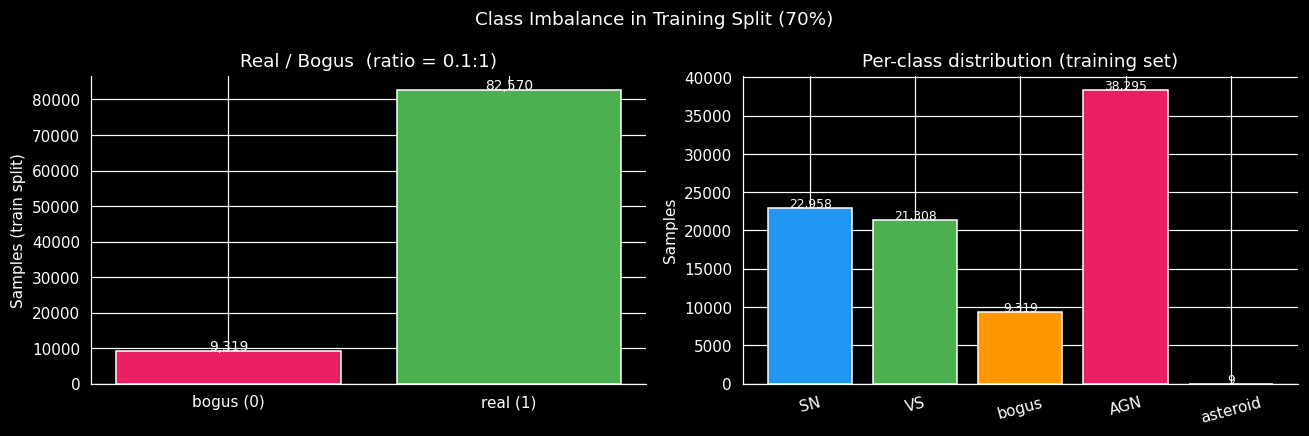

Training samples: 91,889
Real/Bogus ratio: 0.1:1  (bogus >> real)
Class counts: {'SN': 22958, 'VS': 21308, 'bogus': 9319, 'AGN': 38295, 'asteroid': 9}


In [2]:
df = pd.read_csv(LABELS_CSV)
train_df, val_df, test_df = time_split(df)

# Real/bogus split
rb_counts = Counter(REAL_BOGUS_MAP[c] for c in train_df['class'])
class_counts = Counter(train_df['class'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Real vs bogus
ax1.bar(['bogus (0)', 'real (1)'], [rb_counts[0], rb_counts[1]],
        color=['#E91E63','#4CAF50'])
for i, (k, v) in enumerate([(0, rb_counts[0]), (1, rb_counts[1])]):
    ax1.text(i, v + 200, f'{v:,}', ha='center', fontsize=9)
ax1.set_ylabel('Samples (train split)')
ax1.set_title('Real / Bogus balance')
ratio = rb_counts[0] / max(rb_counts[1], 1)
ax1.set_title(f'Real / Bogus  (ratio = {ratio:.1f}:1)')

# Per-class
names = list(class_counts.keys())
vals  = [class_counts[n] for n in names]
bars = ax2.bar(names, vals, color=PALETTE[:len(names)])
for bar, v in zip(bars, vals):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 100, f'{v:,}',
             ha='center', fontsize=8)
ax2.set_ylabel('Samples')
ax2.set_title('Per-class distribution (training set)')
ax2.tick_params(axis='x', rotation=15)

plt.suptitle('Class Imbalance in Training Split (70%)', fontsize=12)
plt.tight_layout()
plt.savefig('../results/class_imbalance.png', bbox_inches='tight', dpi=120)
plt.show()

print(f'Training samples: {len(train_df):,}')
print(f'Real/Bogus ratio: {ratio:.1f}:1  (bogus >> real)')
print(f'Class counts: {dict(class_counts)}')

## 2 — Strategy 1: Focal Loss

Focal loss = `alpha * (1 - p_t)^gamma * BCE`

- When the model is confident and correct (`p_t → 1`), the focal weight → 0 — easy examples are down-weighted.
- When the model is wrong (`p_t → 0`), the focal weight → 1 — hard examples dominate.
- `gamma=2.0` is the spec recommendation.  `alpha=0.25` puts more weight on the positive (real) class.

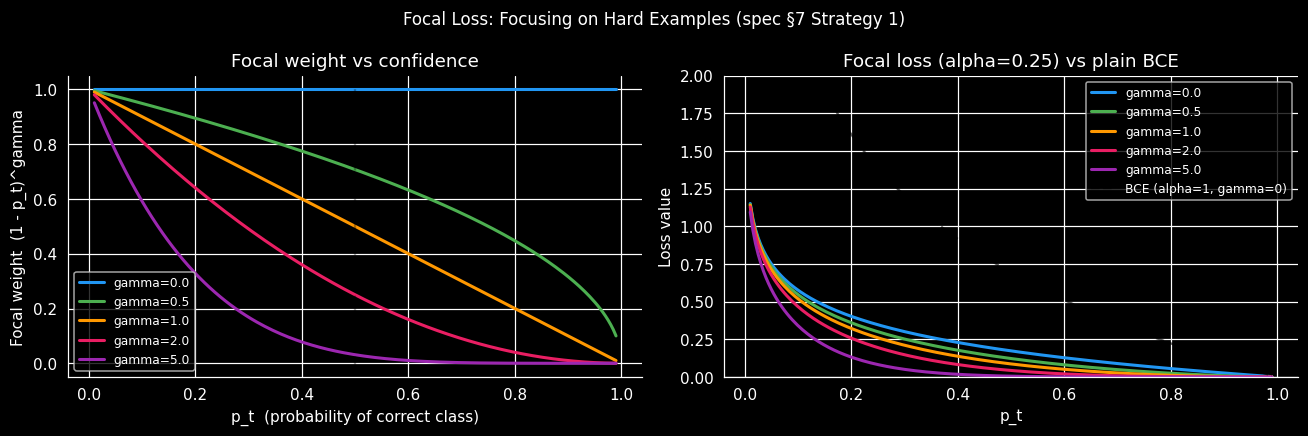

In [3]:
# Visualise focal weight as a function of p_t for various gamma values
p_t = np.linspace(0.01, 0.99, 200)
gammas = [0.0, 0.5, 1.0, 2.0, 5.0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for g, color in zip(gammas, PALETTE):
    weight = (1 - p_t) ** g
    ax1.plot(p_t, weight, linewidth=2, color=color, label=f'gamma={g}')
ax1.set_xlabel('p_t  (probability of correct class)')
ax1.set_ylabel('Focal weight  (1 - p_t)^gamma')
ax1.set_title('Focal weight vs confidence')
ax1.legend(fontsize=8)
ax1.axvline(0.5, color='k', linestyle='--', alpha=0.3)

# BCE vs Focal loss for a positive sample (target=1)
bce_loss = -np.log(p_t)
for g, color in zip(gammas, PALETTE):
    focal = 0.25 * (1 - p_t)**g * bce_loss
    ax2.plot(p_t, focal, linewidth=2, color=color, label=f'gamma={g}')
ax2.plot(p_t, bce_loss, 'k--', linewidth=1.5, alpha=0.6, label='BCE (alpha=1, gamma=0)')
ax2.set_xlabel('p_t')
ax2.set_ylabel('Loss value')
ax2.set_title('Focal loss (alpha=0.25) vs plain BCE')
ax2.legend(fontsize=8)
ax2.set_ylim(0, 2)

plt.suptitle('Focal Loss: Focusing on Hard Examples (spec §7 Strategy 1)', fontsize=11)
plt.tight_layout()
plt.savefig('../results/focal_loss_curve.png', bbox_inches='tight', dpi=120)
plt.show()

In [4]:
# Show FocalLoss implementation and test it
fl_default = FocalLoss(alpha=0.25, gamma=2.0)
fl_high    = FocalLoss(alpha=0.25, gamma=5.0)
bce_plain  = nn.BCEWithLogitsLoss()

torch.manual_seed(0)
# Simulate confident-bogus logits (model mostly predicts 0)
logits_easy = torch.full((32,), -3.0)  # model confident bogus
logits_hard = torch.zeros(32)          # model uncertain
targets = torch.zeros(32)              # all truly bogus

print('=== Easy examples (model confident, correct) ===')
print(f'  BCE loss:             {bce_plain(logits_easy, targets):.4f}')
print(f'  FocalLoss (g=2):      {fl_default(logits_easy, targets):.4f}  ← down-weighted')
print(f'  FocalLoss (g=5):      {fl_high(logits_easy, targets):.4f}  ← heavily down-weighted')

print('\n=== Hard examples (model uncertain) ===')
print(f'  BCE loss:             {bce_plain(logits_hard, targets):.4f}')
print(f'  FocalLoss (g=2):      {fl_default(logits_hard, targets):.4f}  ← not down-weighted')
print(f'  FocalLoss (g=5):      {fl_high(logits_hard, targets):.4f}')

# alpha comparison
alphas = [0.1, 0.25, 0.5, 0.75, 1.0]
targets_pos = torch.ones(32)
logits_mid  = torch.zeros(32)
print('\n=== Alpha effect on positive (real) class loss ===')
for a in alphas:
    l = FocalLoss(alpha=a, gamma=2.0)(logits_mid, targets_pos)
    print(f'  alpha={a:.2f}: {l:.4f}')

=== Easy examples (model confident, correct) ===
  BCE loss:             0.0486
  FocalLoss (g=2):      0.0000  ← down-weighted
  FocalLoss (g=5):      0.0000  ← heavily down-weighted

=== Hard examples (model uncertain) ===
  BCE loss:             0.6931
  FocalLoss (g=2):      0.0433  ← not down-weighted
  FocalLoss (g=5):      0.0054

=== Alpha effect on positive (real) class loss ===
  alpha=0.10: 0.0173
  alpha=0.25: 0.0433
  alpha=0.50: 0.0866
  alpha=0.75: 0.1300
  alpha=1.00: 0.1733


## 3 — Strategy 2: Weighted Random Sampler

The `WeightedRandomSampler` oversamples minority classes so each training batch sees a more balanced class distribution.  Weight per sample = `1 / class_count`.

Training label distribution (unweighted):
  label 0: 9,319 (10.1%)
  label 1: 82,570 (89.9%)


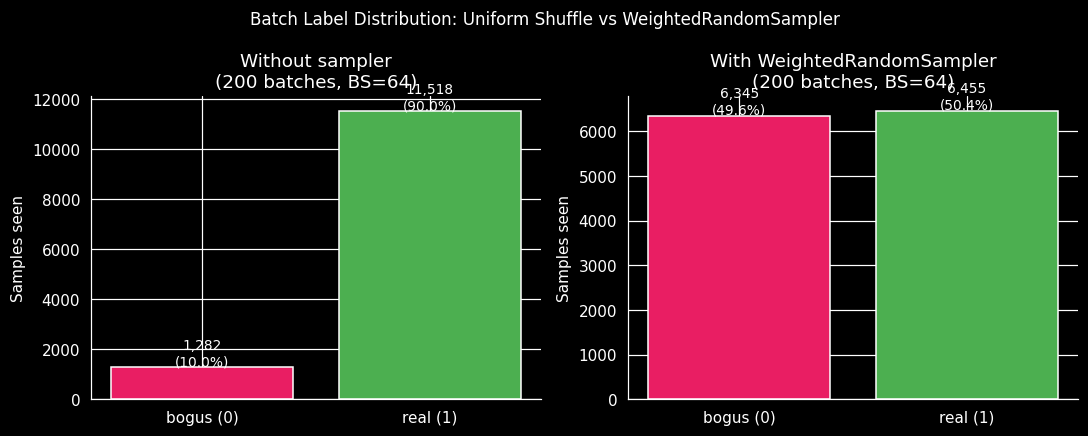

Weighted sampler effective positive rate: 50.4%


In [5]:
# Build train dataset and weighted sampler
train_ds, val_ds, _ = build_datasets(df, task='real_bogus', processed_dir=PROCESSED)
train_labels = train_ds.labels

label_counts = Counter(train_labels)
print('Training label distribution (unweighted):')
for k, v in sorted(label_counts.items()):
    print(f'  label {k}: {v:,} ({v/len(train_labels)*100:.1f}%)')

sampler = make_weighted_sampler(train_labels)

# Simulate what a batch looks like with and without sampler
N_BATCHES = 200
BS = 64

loader_uniform = DataLoader(train_ds, batch_size=BS, shuffle=True)
loader_weighted = DataLoader(train_ds, batch_size=BS, sampler=sampler)

uniform_counts  = Counter()
weighted_counts = Counter()

for i, (_, y) in enumerate(loader_uniform):
    if i >= N_BATCHES: break
    for lbl in y.tolist(): uniform_counts[lbl] += 1

for i, (_, y) in enumerate(loader_weighted):
    if i >= N_BATCHES: break
    for lbl in y.tolist(): weighted_counts[lbl] += 1

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, counts, title in [
    (axes[0], uniform_counts, f'Without sampler\n({N_BATCHES} batches, BS={BS})'),
    (axes[1], weighted_counts, f'With WeightedRandomSampler\n({N_BATCHES} batches, BS={BS})'),
]:
    labels_list = [0, 1]
    names = ['bogus (0)', 'real (1)']
    vals  = [counts.get(l, 0) for l in labels_list]
    total = sum(vals)
    ax.bar(names, vals, color=['#E91E63','#4CAF50'])
    for i, v in enumerate(vals):
        ax.text(i, v + 50, f'{v:,}\n({v/total*100:.1f}%)', ha='center', fontsize=9)
    ax.set_ylabel('Samples seen')
    ax.set_title(title)

plt.suptitle('Batch Label Distribution: Uniform Shuffle vs WeightedRandomSampler', fontsize=11)
plt.tight_layout()
plt.savefig('../results/weighted_sampler_comparison.png', bbox_inches='tight', dpi=120)
plt.show()

print(f'Weighted sampler effective positive rate: {weighted_counts[1]/(weighted_counts[0]+weighted_counts[1])*100:.1f}%')

## 4 — Strategy 3: Class-weighted Cross-Entropy

For the multiclass transient type task, sklearn's `compute_class_weight('balanced')` assigns each class a weight inversely proportional to its frequency:

```
weight_c = n_samples / (n_classes × count_c)
```

Balanced class weights for CrossEntropyLoss:
  bogus         count= 9,319  weight=1.9721
  SN            count=22,958  weight=0.8005
  AGN           count=38,295  weight=0.4799
  VS            count=21,308  weight=0.8625
  asteroid      count=     9  weight=2041.9778


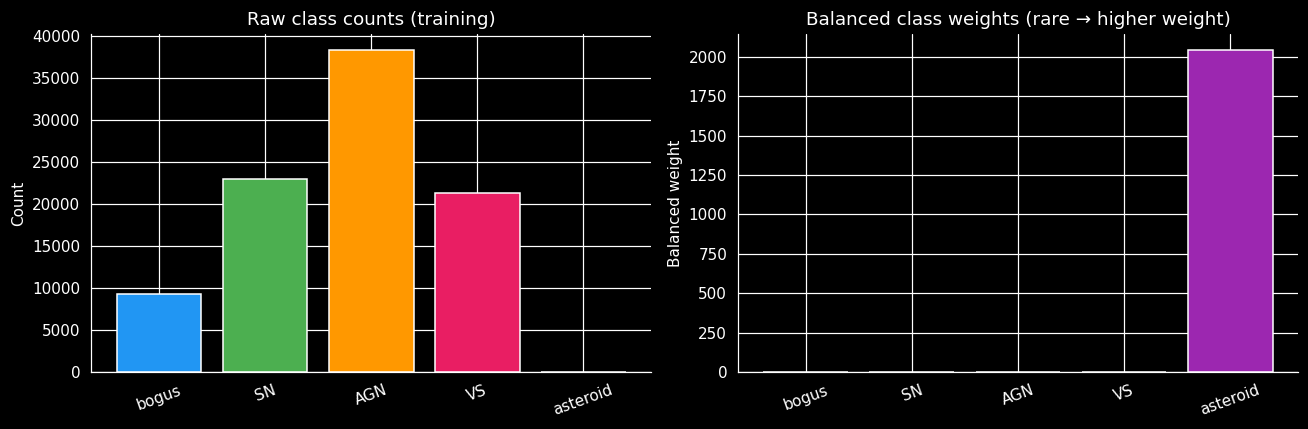

In [6]:
from sklearn.utils.class_weight import compute_class_weight
from src.utils import CLASS_TO_IDX

# Multiclass labels in training split
train_mc_labels = [CLASS_TO_IDX[c] for c in train_df['class']]
class_counts_mc = Counter(train_mc_labels)

classes_arr = np.arange(NUM_CLASSES)
weights = compute_class_weight('balanced', classes=classes_arr, y=np.array(train_mc_labels))

print('Balanced class weights for CrossEntropyLoss:')
for i, (cname, w) in enumerate(zip(CLASS_NAMES, weights)):
    count = class_counts_mc.get(i, 0)
    print(f'  {cname:12s}  count={count:6,}  weight={w:.4f}')

# Visualise: raw counts vs inverse weights
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
raw_counts = [class_counts_mc.get(i, 0) for i in range(NUM_CLASSES)]
ax1.bar(CLASS_NAMES, raw_counts, color=PALETTE)
ax1.set_ylabel('Count')
ax1.set_title('Raw class counts (training)')
ax2.bar(CLASS_NAMES, weights, color=PALETTE)
ax2.set_ylabel('Balanced weight')
ax2.set_title('Balanced class weights (rare → higher weight)')
for ax in [ax1, ax2]:
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('../results/class_weights.png', bbox_inches='tight', dpi=120)
plt.show()

## 5 — Combined Strategy: Focal Loss + Weighted Sampler

Combining both strategies gives the strongest correction:
- **Sampler**: each batch sees balanced classes → no gradient dominated by bogus
- **Focal loss**: additionally down-weights easy bogus within those balanced batches

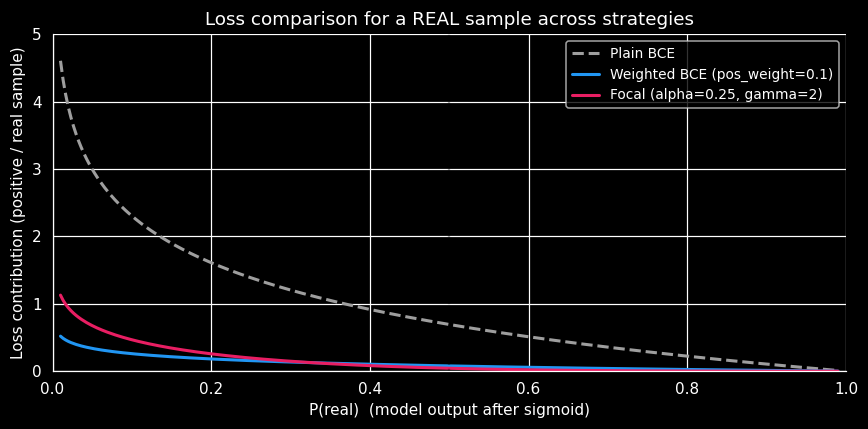

pos_weight for WeightedBCE: 0.11  (n_neg=9,319 / n_pos=82,570)


In [7]:
# Show loss value vs prediction probability for each strategy on a positive (real) sample
p = np.linspace(0.01, 0.99, 300)
bce_raw   = -np.log(p)                          # plain BCE, positive class
focal_loss = 0.25 * (1-p)**2 * (-np.log(p))   # focal alpha=0.25 gamma=2

# pos_weight effect: up-weights the positive class BCE
rb_labels = [REAL_BOGUS_MAP[c] for c in train_df['class']]
n_pos = sum(1 for l in rb_labels if l == 1)
n_neg = sum(1 for l in rb_labels if l == 0)
pos_weight = n_neg / max(n_pos, 1)
weighted_bce = pos_weight * (-np.log(p))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(p, bce_raw,      color='#9E9E9E', linewidth=2, linestyle='--', label='Plain BCE')
ax.plot(p, weighted_bce, color='#2196F3', linewidth=2, label=f'Weighted BCE (pos_weight={pos_weight:.1f})')
ax.plot(p, focal_loss,   color='#E91E63', linewidth=2, label='Focal (alpha=0.25, gamma=2)')
ax.set_xlabel('P(real)  (model output after sigmoid)')
ax.set_ylabel('Loss contribution (positive / real sample)')
ax.set_title('Loss comparison for a REAL sample across strategies')
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 5)
ax.axvline(0.5, color='k', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/loss_comparison.png', bbox_inches='tight', dpi=120)
plt.show()

print(f'pos_weight for WeightedBCE: {pos_weight:.2f}  (n_neg={n_neg:,} / n_pos={n_pos:,})')

## 6 — Effect on Batch Statistics

A quick demonstration that the combined approach changes what the model sees during training.

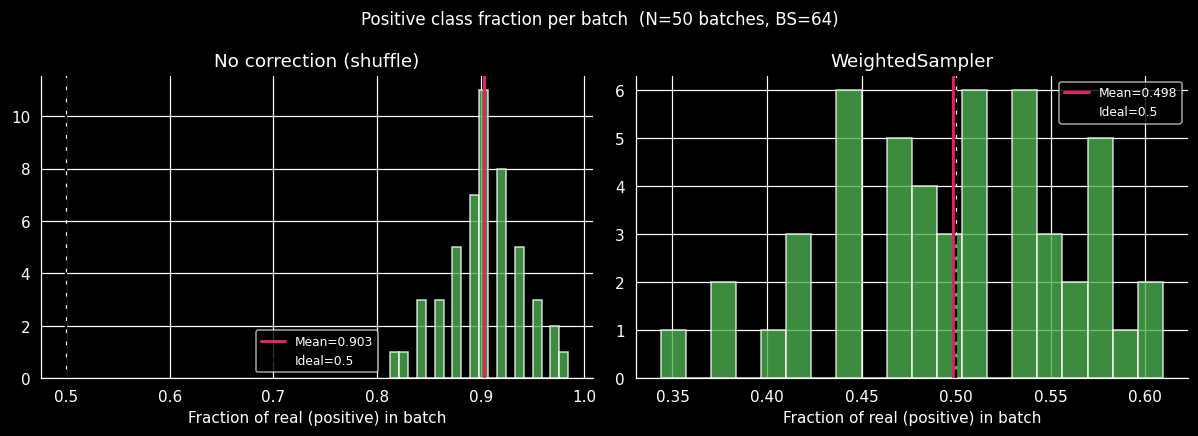

In [8]:
# Show how batch statistics differ across strategies
N_DEMO = 50
strategies = {
    'No correction (shuffle)': DataLoader(train_ds, batch_size=64, shuffle=True),
    'WeightedSampler':         DataLoader(train_ds, batch_size=64, sampler=make_weighted_sampler(train_labels)),
}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, loader) in zip(axes, strategies.items()):
    positive_fracs = []
    for i, (_, y) in enumerate(loader):
        if i >= N_DEMO: break
        positive_fracs.append(y.float().mean().item())
    ax.hist(positive_fracs, bins=20, color='#4CAF50', edgecolor='white', alpha=0.8)
    ax.axvline(np.mean(positive_fracs), color='#E91E63', linewidth=2,
               label=f'Mean={np.mean(positive_fracs):.3f}')
    ax.axvline(0.5, color='k', linewidth=1.5, linestyle='--', label='Ideal=0.5')
    ax.set_xlabel('Fraction of real (positive) in batch')
    ax.set_title(name)
    ax.legend(fontsize=8)
plt.suptitle(f'Positive class fraction per batch  (N={N_DEMO} batches, BS=64)', fontsize=11)
plt.tight_layout()
plt.savefig('../results/batch_balance.png', bbox_inches='tight', dpi=120)
plt.show()

## 7 — Summary

In [9]:
print('='*60)
print('  STAGE 7 — CLASS IMBALANCE STRATEGIES SUMMARY')
print('='*60)

rb_labels_list = [REAL_BOGUS_MAP[c] for c in train_df['class']]
n_real = sum(1 for l in rb_labels_list if l == 1)
n_bogus = sum(1 for l in rb_labels_list if l == 0)

print(f'\nDataset imbalance (training):')
print(f'  Bogus:  {n_bogus:,}  ({n_bogus/(n_bogus+n_real)*100:.1f}%)')
print(f'  Real:   {n_real:,}   ({n_real/(n_bogus+n_real)*100:.1f}%)')
print(f'  Ratio:  {n_bogus/max(n_real,1):.1f}:1')

print('\nStrategies implemented (src/losses.py + src/dataset.py):')
print('  1. FocalLoss(alpha=0.25, gamma=2.0)')
print('     → down-weights easy examples, focuses on hard misclassifications')
print('  2. WeightedRandomSampler (src/dataset.make_weighted_sampler)')
print('     → each batch sees ~50% real, ~50% bogus regardless of true ratio')
print('  3. make_weighted_ce(train_labels) for multiclass CrossEntropyLoss')
print('     → rare classes (asteroid, AGN) get higher loss weight')

print('\nRecommendation for ablation study (spec §11 Ablation 3):')
print('  Strategy  | Expected behaviour')
print('  ----------|-------------------------------------------------')
print('  None       | High accuracy, low recall on real class')
print('  Sampler    | Balanced batches; may overfit to small real set')
print('  Focal      | Best single strategy for imbalanced binary')
print('  Combined   | Use in all final experiments (spec §7 recommendation)')

  STAGE 7 — CLASS IMBALANCE STRATEGIES SUMMARY

Dataset imbalance (training):
  Bogus:  9,319  (10.1%)
  Real:   82,570   (89.9%)
  Ratio:  0.1:1

Strategies implemented (src/losses.py + src/dataset.py):
  1. FocalLoss(alpha=0.25, gamma=2.0)
     → down-weights easy examples, focuses on hard misclassifications
  2. WeightedRandomSampler (src/dataset.make_weighted_sampler)
     → each batch sees ~50% real, ~50% bogus regardless of true ratio
  3. make_weighted_ce(train_labels) for multiclass CrossEntropyLoss
     → rare classes (asteroid, AGN) get higher loss weight

Recommendation for ablation study (spec §11 Ablation 3):
  Strategy  | Expected behaviour
  ----------|-------------------------------------------------
  None       | High accuracy, low recall on real class
  Sampler    | Balanced batches; may overfit to small real set
  Focal      | Best single strategy for imbalanced binary
  Combined   | Use in all final experiments (spec §7 recommendation)
